In [1]:
# ================================
# IMPORT LIBRARY
# ================================
import pandas as pd

# ================================
# LOAD DATASET
# ================================
df = pd.read_csv("32_Streamer_Game.csv")

# ================================
# MENAMPILKAN SEMUA KOLOM
# ================================
pd.set_option('display.max_columns', None)

# ================================
# MENAMPILKAN SEMUA BARIS
# ================================
pd.set_option('display.max_rows', None)

# ================================
# MENAMPILKAN DATASET
# ================================
print(df)

      Streamer_ID  Avg_Viewers  Peak_Viewers  Genre_Type  Donation_Amount  \
0          1001.0       626.38         39.26        6.23            48.23   
1          1002.0       827.44         21.69        0.01            36.58   
2          1003.0       627.32         89.24        3.25            83.39   
3             NaN       616.20         73.08        4.68            15.83   
4          1005.0       166.06         23.88        9.27            44.28   
5          1006.0       398.53         55.40        6.62            12.62   
6             NaN       371.82         45.84        4.41            72.30   
7          1008.0        17.88          8.96        0.95            55.37   
8          1009.0       705.33         61.50        1.27            61.02   
9          1010.0       902.69         53.71        8.79            55.04   
10         1011.0       653.49         48.79        9.91            74.78   
11         1012.0       218.52         59.59        6.36            56.60   

In [2]:
# ================================
# STATISTIK DESKRIPTIF
# ================================

# Ambil hanya kolom numerik
numeric_cols = df.select_dtypes(include=['float64', 'int64'])

# Hitung statistik
statistik = numeric_cols.agg(['mean', 'median', 'std', 'min', 'max'])

# Tampilkan hasil
print("=== STATISTIK DESKRIPTIF ===\n")
print(statistik)

=== STATISTIK DESKRIPTIF ===

        Streamer_ID  Avg_Viewers  Peak_Viewers  Genre_Type  Donation_Amount  \
mean     2552.40306   499.852893     49.294393    4.997958        49.430748   
median   2555.00000   496.410000     48.270000    4.940000        49.810000   
std       895.43892   283.440239     28.963459    2.903949        28.910800   
min      1001.00000     0.090000      0.030000    0.000000         0.040000   
max      4100.00000   999.920000     99.970000   10.000000        99.960000   

        Hours_Streamed  
mean        495.441367  
median      494.470000  
std         291.357019  
min           0.020000  
max         999.880000  


In [3]:
# ================================
# ANALISIS ANOMALI
# ================================

print("=== ANALISIS NILAI MIN & MAX ===\n")

# Ambil kolom numerik
numeric_cols = df.select_dtypes(include=['float64', 'int64'])

# Tampilkan min dan max
for col in numeric_cols.columns:
    print(f"{col}")
    print(f"  Min : {df[col].min()}")
    print(f"  Max : {df[col].max()}")
    print()

# ================================
# CEK DUPLIKASI ID
# ================================

print("=== CEK DUPLIKASI STREAMER_ID ===\n")

duplikat_id = df['Streamer_ID'].duplicated().sum()
print(f"Jumlah ID duplikat: {duplikat_id}")

# ================================
# CEK NILAI TIDAK WAJAR
# ================================

print("\n=== CEK NILAI TIDAK WAJAR ===\n")

# Contoh: nilai negatif atau nol ekstrem
for col in numeric_cols.columns:
    jumlah_nol = (df[col] == 0).sum()
    jumlah_negatif = (df[col] < 0).sum()
    
    print(f"{col}")
    print(f"  Nilai = 0      : {jumlah_nol}")
    print(f"  Nilai negatif  : {jumlah_negatif}")
    print()

=== ANALISIS NILAI MIN & MAX ===

Streamer_ID
  Min : 1001.0
  Max : 4100.0

Avg_Viewers
  Min : 0.09
  Max : 999.92

Peak_Viewers
  Min : 0.03
  Max : 99.97

Genre_Type
  Min : 0.0
  Max : 10.0

Donation_Amount
  Min : 0.04
  Max : 99.96

Hours_Streamed
  Min : 0.02
  Max : 999.88

=== CEK DUPLIKASI STREAMER_ID ===

Jumlah ID duplikat: 92

=== CEK NILAI TIDAK WAJAR ===

Streamer_ID
  Nilai = 0      : 0
  Nilai negatif  : 0

Avg_Viewers
  Nilai = 0      : 0
  Nilai negatif  : 0

Peak_Viewers
  Nilai = 0      : 0
  Nilai negatif  : 0

Genre_Type
  Nilai = 0      : 2
  Nilai negatif  : 0

Donation_Amount
  Nilai = 0      : 0
  Nilai negatif  : 0

Hours_Streamed
  Nilai = 0      : 0
  Nilai negatif  : 0



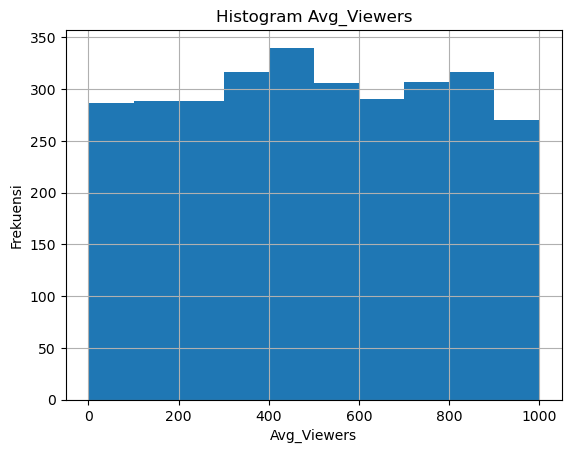

=== ANALISIS DISTRIBUSI ===

Nilai Skewness: -0.0075316191268565555
Distribusi miring ke kiri (negatively skewed)


In [4]:
# ================================
# VISUALISASI DISTRIBUSI
# ================================

import matplotlib.pyplot as plt

# Pilih kolom numerik utama
kolom = 'Avg_Viewers'

# ================================
# HISTOGRAM
# ================================
plt.figure()
df[kolom].hist()

plt.title(f'Histogram {kolom}')
plt.xlabel(kolom)
plt.ylabel('Frekuensi')

plt.show()

# ================================
# CEK SKEWNESS
# ================================
skewness = df[kolom].skew()

print("=== ANALISIS DISTRIBUSI ===\n")
print(f"Nilai Skewness: {skewness}")

if skewness > 0:
    print("Distribusi miring ke kanan (positively skewed)")
elif skewness < 0:
    print("Distribusi miring ke kiri (negatively skewed)")
else:
    print("Distribusi simetris (normal)")

In [ ]:
# ================================
# CEK MISSING VALUES
# ================================

print("=== CEK MISSING VALUES ===\n")

missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

# Gabungkan jadi tabel
missing_table = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_percent
})

print(missing_table)

# ================================
# KESIMPULAN AWAL
# ================================
print("\n=== ANALISIS MISSING VALUES ===\n")

for col in df.columns:
    if missing[col] > 0:
        print(f"{col} memiliki {missing[col]} missing value ({missing_percent[col]:.2f}%)")
    else:
        print(f"{col} tidak memiliki missing value")

# ================================
# PENANGANAN MISSING VALUES
# ================================

    print("\n=== PENANGANAN MISSING VALUES ===\n")

    # Kolom numerik → imputasi mean
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

    for col in numeric_cols:
        if df[col].isna().sum() > 0:
            mean_val = df[col].mean()
            df[col].fillna(mean_val, inplace=True)
            print(f"{col} → diisi dengan MEAN ({mean_val:.2f})")

    # Kolom kategori → imputasi modus
    categorical_cols = df.select_dtypes(include=['object']).columns

    for col in categorical_cols:
        if df[col].isna().sum() > 0:
            mode_val = df[col].mode()[0]
            df[col].fillna(mode_val, inplace=True)
            print(f"{col} → diisi dengan MODUS ({mode_val})")

    # ================================
    # CEK ULANG
    # ================================
    print("\n=== CEK ULANG MISSING VALUES ===\n")
    print(df.isna().sum())

=== CEK MISSING VALUES ===

                 Jumlah Missing  Persentase (%)
Streamer_ID                  93             3.0
Avg_Viewers                  93             3.0
Peak_Viewers                 93             3.0
Genre_Type                   93             3.0
Donation_Amount              93             3.0
Hours_Streamed               93             3.0
Platform_Type                93             3.0

=== ANALISIS MISSING VALUES ===

Streamer_ID memiliki 93 missing value (3.00%)
Avg_Viewers memiliki 93 missing value (3.00%)
Peak_Viewers memiliki 93 missing value (3.00%)
Genre_Type memiliki 93 missing value (3.00%)
Donation_Amount memiliki 93 missing value (3.00%)
Hours_Streamed memiliki 93 missing value (3.00%)
Platform_Type memiliki 93 missing value (3.00%)

=== PENANGANAN MISSING VALUES ===

Streamer_ID → diisi dengan MEAN (2552.40)
Avg_Viewers → diisi dengan MEAN (499.85)
Peak_Viewers → diisi dengan MEAN (49.29)
Genre_Type → diisi dengan MEAN (5.00)
Donation_Amount → diisi d

C:\Users\DELL\AppData\Local\Temp\ipykernel_12276\1139724405.py:41: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mean_val, inplace=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_12276\1139724405.py:50: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when

In [6]:
# ================================
# CEK DATA SEBELUM STANDARDISASI
# ================================

print("=== SEBELUM STANDARDISASI ===\n")
print(df['Platform_Type'].unique())

# ================================
# PROSES STANDARDISASI
# ================================

# 1. Menghapus spasi berlebih
df['Platform_Type'] = df['Platform_Type'].str.strip()

# 2. Mengubah semua huruf menjadi lowercase
df['Platform_Type'] = df['Platform_Type'].str.lower()

# ================================
# CEK DATA SETELAH STANDARDISASI
# ================================

print("\n=== SETELAH STANDARDISASI ===\n")
print(df['Platform_Type'].unique())

=== SEBELUM STANDARDISASI ===

['Unknown' 'Low' 'High' 'Medium']

=== SETELAH STANDARDISASI ===

['unknown' 'low' 'high' 'medium']


=== DETEKSI OUTLIER (IQR) ===

Streamer_ID
Jumlah outlier: 0
Batas bawah : -461.0
Batas atas  : 5565.0

Avg_Viewers
Jumlah outlier: 0
Batas bawah : -431.92500000000007
Batas atas  : 1435.875

Peak_Viewers
Jumlah outlier: 0
Batas bawah : -49.223749999999974
Batas atas  : 147.30624999999998

Genre_Type
Jumlah outlier: 0
Batas bawah : -4.55625
Batas atas  : 14.57375

Donation_Amount
Jumlah outlier: 0
Batas bawah : -49.168749999999996
Batas atas  : 147.30124999999998

Hours_Streamed
Jumlah outlier: 0
Batas bawah : -492.3824999999998
Batas atas  : 1481.9574999999998



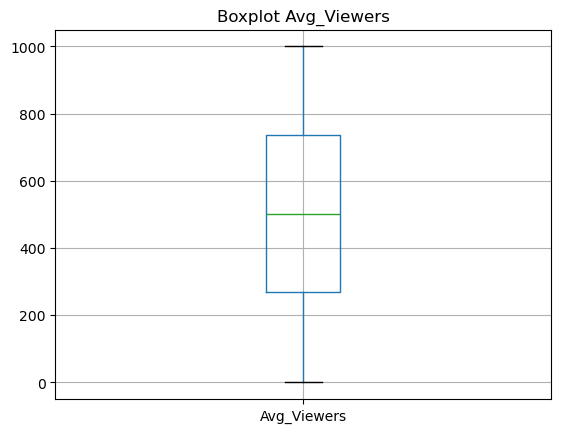

In [10]:
# ================================
# DETEKSI OUTLIER DENGAN IQR
# ================================
import matplotlib.pyplot as plt
print("=== DETEKSI OUTLIER (IQR) ===\n")

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    # mencari outlier
    outlier = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}")
    print(f"Jumlah outlier: {len(outlier)}")
    print(f"Batas bawah : {lower_bound}")
    print(f"Batas atas  : {upper_bound}")
    print()
   

plt.figure()
df.boxplot(column='Avg_Viewers')
plt.title('Boxplot Avg_Viewers')
plt.show()

In [11]:
# ================================
# FEATURE SCALING (MIN-MAX)
# ================================

print("=== SEBELUM SCALING ===\n")
print(df[['Avg_Viewers', 'Peak_Viewers', 'Donation_Amount', 'Hours_Streamed']].head())

# pilih kolom numerik (kecuali ID)
cols = ['Avg_Viewers', 'Peak_Viewers', 'Donation_Amount', 'Hours_Streamed']

# salin data
df_scaled = df.copy()

# rumus Min-Max Scaling
for col in cols:
    min_val = df[col].min()
    max_val = df[col].max()
    
    df_scaled[col] = (df[col] - min_val) / (max_val - min_val)

print("\n=== SESUDAH SCALING ===\n")
print(df_scaled[cols].head())

=== SEBELUM SCALING ===

   Avg_Viewers  Peak_Viewers  Donation_Amount  Hours_Streamed
0       626.38         39.26            48.23          219.55
1       827.44         21.69            36.58          697.08
2       627.32         89.24            83.39          165.62
3       616.20         73.08            15.83           87.19
4       166.06         23.88            44.28          197.67

=== SESUDAH SCALING ===

   Avg_Viewers  Peak_Viewers  Donation_Amount  Hours_Streamed
0     0.626396      0.392536         0.482286        0.219561
1     0.827491      0.216730         0.365693        0.697158
2     0.627337      0.892636         0.834167        0.165623
3     0.616215      0.730939         0.158026        0.087182
4     0.165998      0.238643         0.442754        0.197678


In [12]:
# ================================
# ENCODING DATA KATEGORIKAL
# ================================

print("=== SEBELUM ENCODING ===\n")
print(df[['Platform_Type']].head())

# One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=['Platform_Type'])

print("\n=== SESUDAH ENCODING ===\n")
print(df_encoded.head())

=== SEBELUM ENCODING ===

  Platform_Type
0       unknown
1           low
2       unknown
3          high
4       unknown

=== SESUDAH ENCODING ===

   Streamer_ID  Avg_Viewers  Peak_Viewers  Genre_Type  Donation_Amount  \
0   1001.00000       626.38         39.26        6.23            48.23   
1   1002.00000       827.44         21.69        0.01            36.58   
2   1003.00000       627.32         89.24        3.25            83.39   
3   2552.40306       616.20         73.08        4.68            15.83   
4   1005.00000       166.06         23.88        9.27            44.28   

   Hours_Streamed  Platform_Type_high  Platform_Type_low  \
0          219.55               False              False   
1          697.08               False               True   
2          165.62               False              False   
3           87.19                True              False   
4          197.67               False              False   

   Platform_Type_medium  Platform_Type_unknow

In [13]:
# ================================
# FEATURE ENGINEERING
# ================================

print("=== SEBELUM FEATURE ENGINEERING ===\n")
print(df[['Avg_Viewers', 'Peak_Viewers']].head())

# Membuat kolom baru: Engagement Ratio
df['Engagement_Ratio'] = df['Avg_Viewers'] / df['Peak_Viewers']

print("\n=== SESUDAH FEATURE ENGINEERING ===\n")
print(df[['Avg_Viewers', 'Peak_Viewers', 'Engagement_Ratio']].head())

=== SEBELUM FEATURE ENGINEERING ===

   Avg_Viewers  Peak_Viewers
0       626.38         39.26
1       827.44         21.69
2       627.32         89.24
3       616.20         73.08
4       166.06         23.88

=== SESUDAH FEATURE ENGINEERING ===

   Avg_Viewers  Peak_Viewers  Engagement_Ratio
0       626.38         39.26         15.954661
1       827.44         21.69         38.148456
2       627.32         89.24          7.029583
3       616.20         73.08          8.431856
4       166.06         23.88          6.953936
